### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [8]:
tienda['Precio'].sum()

np.float64(1150880400.0)

In [11]:
# Calcular la facturación total individualmente
facturacion_t1 = tienda['Precio'].sum()
facturacion_t2 = tienda2['Precio'].sum()
facturacion_t3 = tienda3['Precio'].sum()
facturacion_t4 = tienda4['Precio'].sum()

In [12]:
# Crear un DataFrame de resumen
df_facturacion = pd.DataFrame({
    'Facturación': [facturacion_t1, facturacion_t2, facturacion_t3, facturacion_t4]
}, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])

<Axes: title={'center': 'Distribución de Facturación Total por Tienda'}, ylabel='Facturación'>

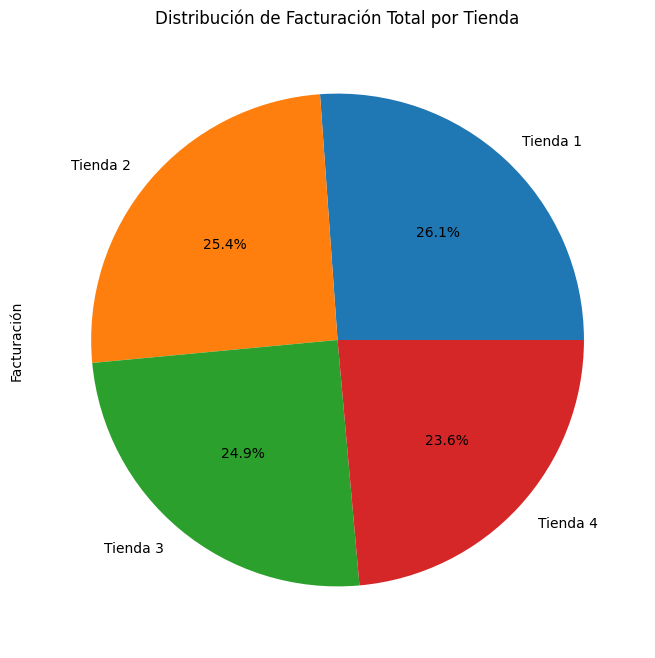

In [13]:
# Gráfico circular
df_facturacion.plot.pie(y='Facturación', figsize=(8, 8), autopct='%1.1f%%',
                        legend=False, title='Distribución de Facturación Total por Tienda')

# 2. Ventas por categoría

In [14]:
# Contar las categorías vendidas en cada dataframe por separado
cat_t1 = tienda['Categoría del Producto'].value_counts()
cat_t2 = tienda2['Categoría del Producto'].value_counts()
cat_t3 = tienda3['Categoría del Producto'].value_counts()
cat_t4 = tienda4['Categoría del Producto'].value_counts()

In [15]:
# Consolidar los conteos en un nuevo DataFrame
ventas_categoria = pd.DataFrame({
    'Tienda 1': cat_t1,
    'Tienda 2': cat_t2,
    'Tienda 3': cat_t3,
    'Tienda 4': cat_t4
}).fillna(0) # Rellenar con 0 si no hay ventas en alguna categoría

In [17]:
print("\nCantidad de Ventas por Categoría:\n")
display(ventas_categoria)


Cantidad de Ventas por Categoría:



,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


<Axes: title={'center': 'Cantidad de Productos Vendidos por Categoría y Tienda'}, xlabel='Tienda', ylabel='Cantidad de Unidades Vendidas'>

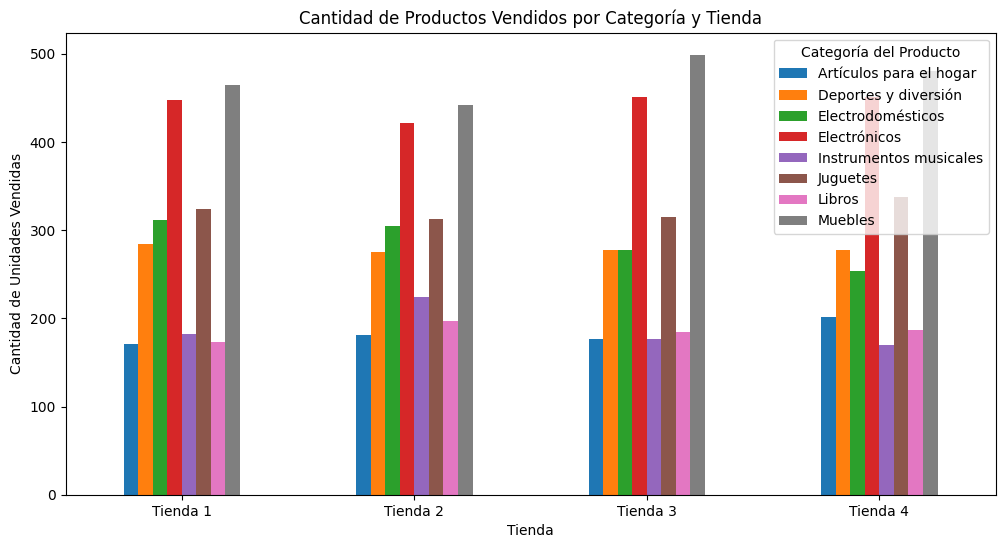

In [25]:
# Gráfico de barras nativo
ventas_categoria.T.plot.bar(figsize=(12, 6),
                            title='Cantidad de Productos Vendidos por Categoría y Tienda',
                            ylabel='Cantidad de Unidades Vendidas',
                            xlabel='Tienda',
                            rot=0)

# 3. Calificación promedio de la tienda


In [26]:
# Calcular el promedio de calificación para cada dataframe
calif_t1 = tienda['Calificación'].mean()
calif_t2 = tienda2['Calificación'].mean()
calif_t3 = tienda3['Calificación'].mean()
calif_t4 = tienda4['Calificación'].mean()

In [27]:
df_calificaciones = pd.DataFrame({
    'Calificación Promedio': [calif_t1, calif_t2, calif_t3, calif_t4]
}, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']).sort_values(by='Calificación Promedio', ascending=False)

In [28]:
print("\nCalificación Promedio por Tienda:\n")
display(df_calificaciones)


Calificación Promedio por Tienda:



,Calificación Promedio
Tienda 3,4.048326
Tienda 2,4.037304
Tienda 4,3.995759
Tienda 1,3.976685


# 4. Productos más y menos vendidos

In [29]:
dfs = [('Tienda 1', tienda), ('Tienda 2', tienda2), ('Tienda 3', tienda3), ('Tienda 4', tienda4)]

In [40]:
resumen_productos = {}

for nombre, df_actual in dfs:
    top_3 = df_actual['Producto'].value_counts().nlargest(3).index.tolist()
    bottom_3 = df_actual['Producto'].value_counts().nsmallest(3).index.tolist()
    resumen_productos[nombre] = {
        'Top 3 Más Vendidos': ", ".join(top_3),
        'Top 3 Menos Vendidos': ", ".join(bottom_3)
    }

In [41]:
df_productos = pd.DataFrame(resumen_productos).T

print("Resumen de Productos MÁS y MENOS vendidos por tienda:\n")
display(df_productos)

Resumen de Productos MÁS y MENOS vendidos por tienda:



,Top 3 Más Vendidos,Top 3 Menos Vendidos
Tienda 1,"Microondas, TV LED UHD 4K, Armario","Auriculares con micrófono, Celular ABXY, Olla ..."
Tienda 2,"Iniciando en programación, Microondas, Batería","Juego de mesa, Mesa de comedor, Impresora"
Tienda 3,"Kit de bancas, Mesa de comedor, Cama king","Bloques de construcción, Set de vasos, Mochila"
Tienda 4,"Cama box, Cubertería, Dashboards con Power BI","Guitarra eléctrica, Armario, Guitarra acústica"


# 5. Envío promedio por tienda

*   List item
*   List item



In [32]:
envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()

In [37]:
df_envios = pd.DataFrame({
    'Costo de Envío Promedio': [envio_t1, envio_t2, envio_t3, envio_t4]
}, index=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])

<Axes: title={'center': 'Costo de Envío Promedio por Tienda'}, xlabel='Tienda', ylabel='Costo Promedio ($)'>

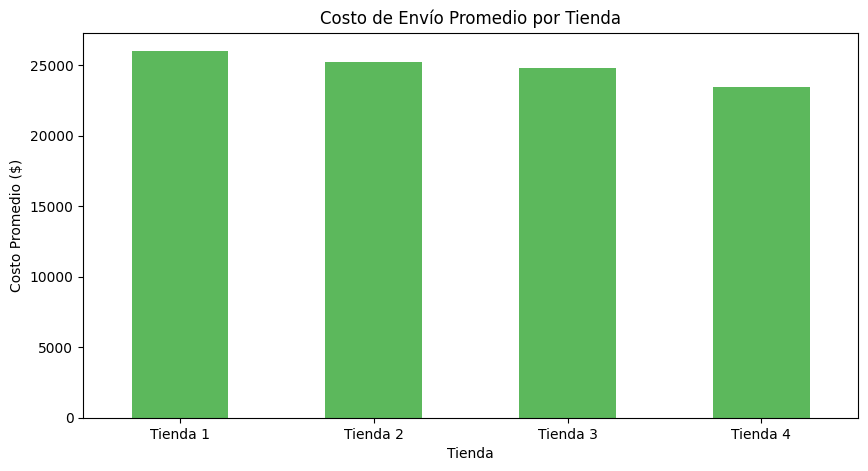

In [39]:
df_envios.plot.bar(y='Costo de Envío Promedio',
                   figsize=(10, 5),
                   title='Costo de Envío Promedio por Tienda',
                   ylabel='Costo Promedio ($)',
                   xlabel='Tienda',
                   rot=0,
                   legend=False,
                   color='#5CB85C')

# Conclusión

Basado en el análisis exhaustivo de los datos de las cuatro sucursales de **Alura Store**, la recomendación estratégica para el Sr. Juan es **vender la Tienda 4** para financiar su nuevo emprendimiento.

A continuación, se detallan los hallazgos clave que sustentan esta decisión:

1. **Menor Eficiencia Financiera (Facturación):** Aunque las cuatro tiendas procesan prácticamente el mismo volumen de pedidos , la **Tienda 4 genera la facturación más baja** con \$1,038 millones, en contraste con los \$1,150 millones de la Tienda 1 (la más rentable). Esto indica que la Tienda 4 requiere el mismo esfuerzo operativo y logístico, pero produce menores ingresos netos, debido a que sus productos estrella son de menor valor comercial (como *Cama box* y *Cubertería*).

2. **Ventaja Logística Desaprovechada:** La Tienda 4 ofrece el costo de envío promedio más bajo (\$23,459). En teoría, esto debería atraer a más clientes o generar mayor satisfacción, pero los datos muestran que **no hay un aumento en el volumen de ventas** y su calificación promedio de satisfacción (4.00/5.0) sigue estando por debajo de líderes como la Tienda 3 (4.05/5.0).


**En conclusión:** Liquidar la **Tienda 4** es la decisión más inteligente. Permite al Sr. Juan obtener el capital necesario para su nuevo proyecto sin sacrificar la rentabilidad general ni la reputación de la marca Alura Store.